# Visualising with PCA

Used PowerTransformer (Yeo-Johnson)


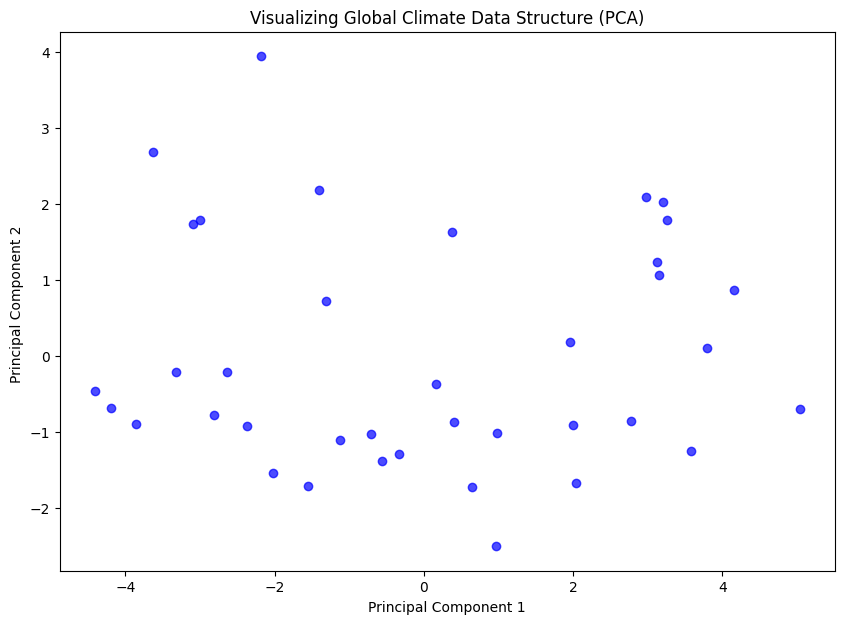

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', ''))) 

from src.preprocessing import preprocess_dataset
from src.preprocessing import preprocess_dataset

# Scale the data using the method from my script... 
X_scaled = preprocess_dataset('../data/processed/cleaned_feature_matrix.csv',
                             '../data/processed/cleaned_and_scaled.csv',
                             method='power')




# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c='blue')
plt.title("Visualizing Global Climate Data Structure (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2 ")
plt.show()

# Visualising with Autoencoder (MLPRegressor Proxy)

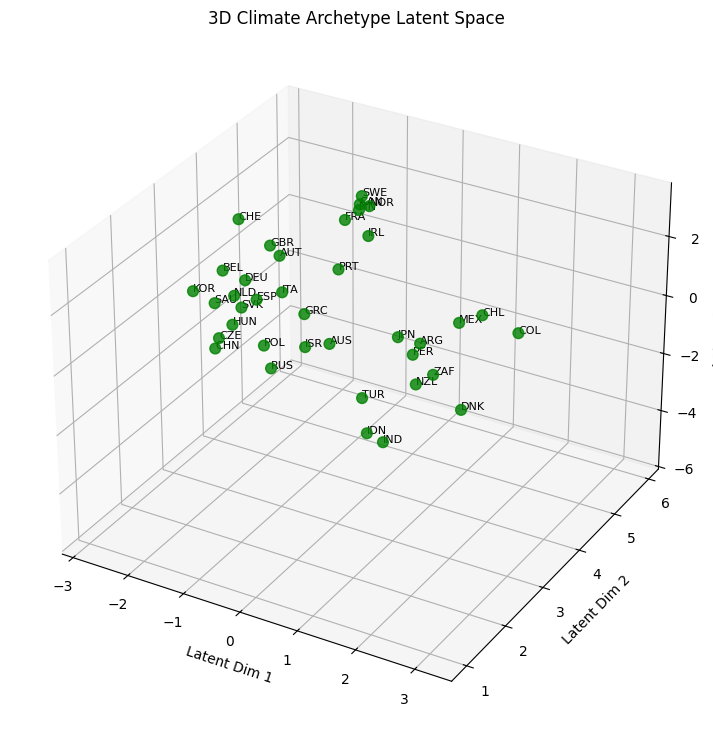

In [37]:
from sklearn.neural_network import MLPRegressor
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

# Get the list of countries from the original dataset for labeling
countries = pd.read_csv('../data/processed/cleaned_feature_matrix.csv')['country_code'].values

# Architecture
ae_3d = MLPRegressor(
    hidden_layer_sizes=(3,), 
    activation='relu', 
    solver='lbfgs',      
    max_iter=2000,       # Increased for the extra complexity
    random_state=42
)

# Train
ae_3d.fit(X_scaled, X_scaled)

# Extract the latent space representation
weights = ae_3d.coefs_[0]
biases = ae_3d.intercepts_[0]
X_ae_3d = np.dot(X_scaled, weights) + biases

# 3D Visualization
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_ae_3d[:, 0], X_ae_3d[:, 1], X_ae_3d[:, 2], 
                     alpha=0.8, c='green', s=60)

for i in range(len(countries)):
    ax.text(X_ae_3d[i, 0], X_ae_3d[i, 1], X_ae_3d[i, 2], 
            countries[i], size=8, zorder=1, color='black')

ax.set_title("3D Climate Archetype Latent Space")
ax.set_xlabel("Latent Dim 1")
ax.set_ylabel("Latent Dim 2")
ax.set_zlabel("Latent Dim 3")

plt.show()

# Visualising with pytorch Autoencoder

In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(101)

# Define the Autoencoder architecture
class ClimateAE(nn.Module):
    def __init__(self, input_dim):
        super(ClimateAE, self).__init__()
        # Encoder: Compressing from many features down to 3
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3) # Latent Space (3D)
        )
        # Decoder: Reconstructing from 3 back to original dimensions
        self.decoder = nn.Sequential(
            nn.Linear(3, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Prepping data
# Convert scaled data to PyTorch tensor

df = X_scaled.copy()
X_tensor = torch.FloatTensor(df.values)

# Initialize the model, define loss function and optimizer
input_dim = df.shape[1]
model = ClimateAE(input_dim)
criterion = nn.MSELoss()


optimizer = optim.Adam(model.parameters(), lr=0.01) 
epochs = 500

for epoch in range(epochs):
    model.train()
    latent_space, decoded = model(X_tensor)
    loss = criterion(decoded, X_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

# Extract the 3D latent space representation
with torch.no_grad():
    X_ae_3d, _ = model(X_tensor)
    X_ae_3d = X_ae_3d.numpy() # Convert back to numpy for visualization


Epoch [100/500], Loss: 0.367987
Epoch [200/500], Loss: 0.194172
Epoch [300/500], Loss: 0.150192
Epoch [400/500], Loss: 0.138030
Epoch [500/500], Loss: 0.131319


In [93]:
from sklearn.cluster import KMeans
import plotly.express as px
import pandas as pd
from sklearn.metrics import silhouette_score

# Cluster the 3d space i got from the autoencoder
n_archetypes = 4 
kmeans = KMeans(n_clusters=n_archetypes, random_state=42, n_init=10)
neural_clusters = kmeans.fit_predict(X_ae_3d)

score = silhouette_score(X_ae_3d, neural_clusters)
print(f"--- Cluster Trust Score ---")
print(f"Silhouette Score: {score:.4f}")

# Mapping the 3D coordinates back to country names and their new cluster IDs
df_archetypes = pd.DataFrame(X_ae_3d, columns=['Latent_1', 'Latent_2', 'Latent_3'])
df_archetypes['Country'] = countries
df_archetypes['Cluster'] = neural_clusters.astype(str) # String for discrete colors

# 3D plot
fig = px.scatter_3d(
    df_archetypes, 
    x='Latent_1', y='Latent_2', z='Latent_3',
    color='Cluster',
    hover_name='Country',
    title=f"Neural Climate Archetypes (Trust Score: {score:.3f})",
    labels={'Latent_1': 'Economic Structure', 'Latent_2': 'Energy Mix', 'Latent_3': 'Policy Path'},
    template='plotly_dark',
    opacity=0.8
)

# renders the interactive plot
fig.show()

--- Cluster Trust Score ---
Silhouette Score: 0.4053


# Trying Hierarchical Clustering

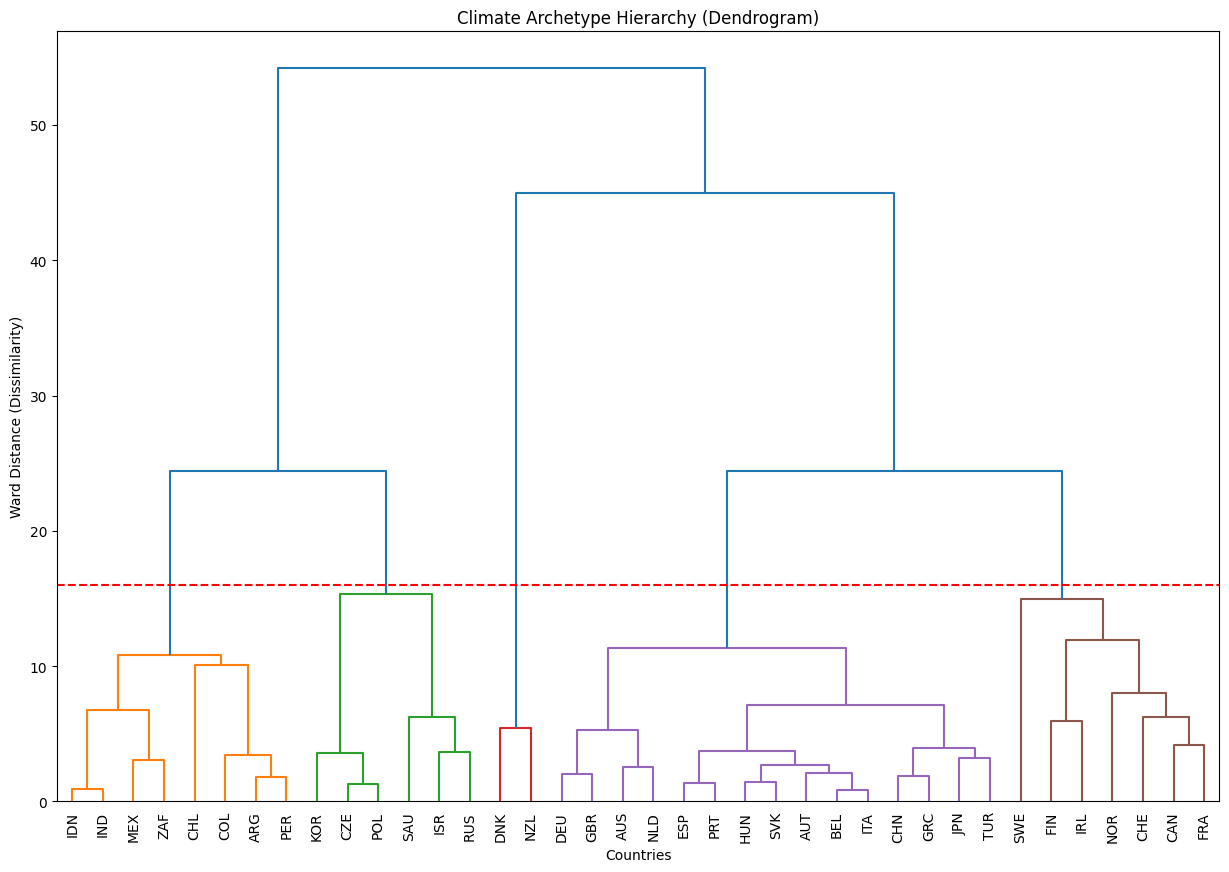

--- Clusters at Cut Line (Distance = 16) ---
Cluster 1: ['ARG', 'CHL', 'COL', 'IDN', 'IND', 'MEX', 'PER', 'ZAF']
Cluster 4: ['AUS', 'AUT', 'BEL', 'CHN', 'DEU', 'ESP', 'GBR', 'GRC', 'HUN', 'ITA', 'JPN', 'NLD', 'PRT', 'SVK', 'TUR']
Cluster 5: ['CAN', 'CHE', 'FIN', 'FRA', 'IRL', 'NOR', 'SWE']
Cluster 2: ['CZE', 'ISR', 'KOR', 'POL', 'RUS', 'SAU']
Cluster 3: ['DNK', 'NZL']


In [126]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15, 10))
# Create the linkage matrix
linkage_matrix = sch.linkage(X_ae_3d, method='ward')

# Plot the Dendrogram
dendrogram = sch.dendrogram(
    linkage_matrix, 
    labels=countries, 
    leaf_rotation=90, 
    leaf_font_size=10,
    color_threshold=16
)

plt.title("Climate Archetype Hierarchy (Dendrogram)")
plt.xlabel("Countries")
plt.ylabel("Ward Distance (Dissimilarity)")
plt.axhline(y=16, color='r', linestyle='--') 
plt.show()

# Print the clusters that are formed at the cut line (distance = 16)
# Print in form "cluster_id: [country1, country2, ...]"
from scipy.cluster.hierarchy import fcluster
# Get cluster labels based on the cut line at distance = 16
cluster_labels = fcluster(linkage_matrix, t=16, criterion='distance')
clusters = {}
for country, label in zip(countries, cluster_labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(country)
print("--- Clusters at Cut Line (Distance = 16) ---")
for cluster_id, country_list in clusters.items():
    print(f"Cluster {cluster_id}: {country_list}")

    

# Trying DBSCAN (bit of a fail)

In [107]:
# Maybe DBSCAN would be better?

from sklearn.cluster import DBSCAN

# eps: The maximum distance between two countries to be considered neighbors
# min_samples: Min countries to form a cluster (trying with 3 to start)
dbscan = DBSCAN(eps=6, min_samples=3) 
neural_clusters = dbscan.fit_predict(X_ae_3d)

# DBSCAN labels outliers as -1
n_clusters = len(set(neural_clusters)) - (1 if -1 in neural_clusters else 0)
n_noise = list(neural_clusters).count(-1)

print(f"Number of Archetypes found: {n_clusters}")
print(f"Number of 'Outlier' Countries: {n_noise}")

Number of Archetypes found: 1
Number of 'Outlier' Countries: 3


In [108]:
# Identify the outliers
outliers = [countries[i] for i, cluster in enumerate(neural_clusters) if cluster == -1]

# Identify the core groups
group_0 = [countries[i] for i, cluster in enumerate(neural_clusters) if cluster == 0]
group_1 = [countries[i] for i, cluster in enumerate(neural_clusters) if cluster == 1]

print(f"--- The Climate outliers --- \n{outliers}\n")
print(f"--- Archetype 0 --- \n{group_0}\n")
print(f"--- Archetype 1 --- \n{group_1}")

--- The Climate outliers --- 
['DNK', 'NZL', 'SWE']

--- Archetype 0 --- 
['ARG', 'AUS', 'AUT', 'BEL', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'CZE', 'DEU', 'ESP', 'FIN', 'FRA', 'GBR', 'GRC', 'HUN', 'IDN', 'IND', 'IRL', 'ISR', 'ITA', 'JPN', 'KOR', 'MEX', 'NLD', 'NOR', 'PER', 'POL', 'PRT', 'RUS', 'SAU', 'SVK', 'TUR', 'ZAF']

--- Archetype 1 --- 
[]


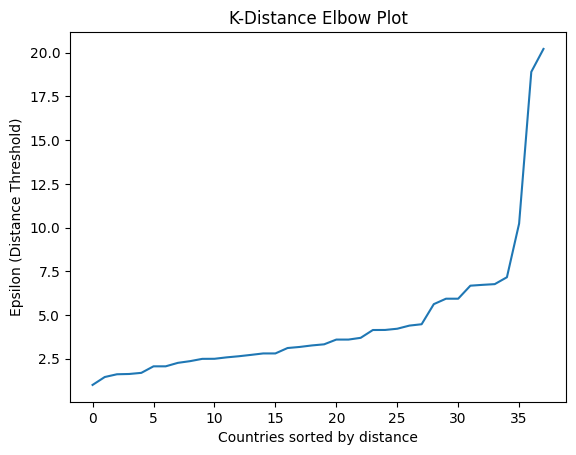

In [103]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Look at the distance to the 3rd nearest neighbor (min_samples - 1)
neigh = NearestNeighbors(n_neighbors=3)
nbrs = neigh.fit(X_ae_3d)
distances, indices = nbrs.kneighbors(X_ae_3d)

# Sort and plot the distances
distances = np.sort(distances[:, 2], axis=0)
plt.plot(distances)
plt.title("K-Distance Elbow Plot")
plt.ylabel("Epsilon (Distance Threshold)")
plt.xlabel("Countries sorted by distance")
plt.show()

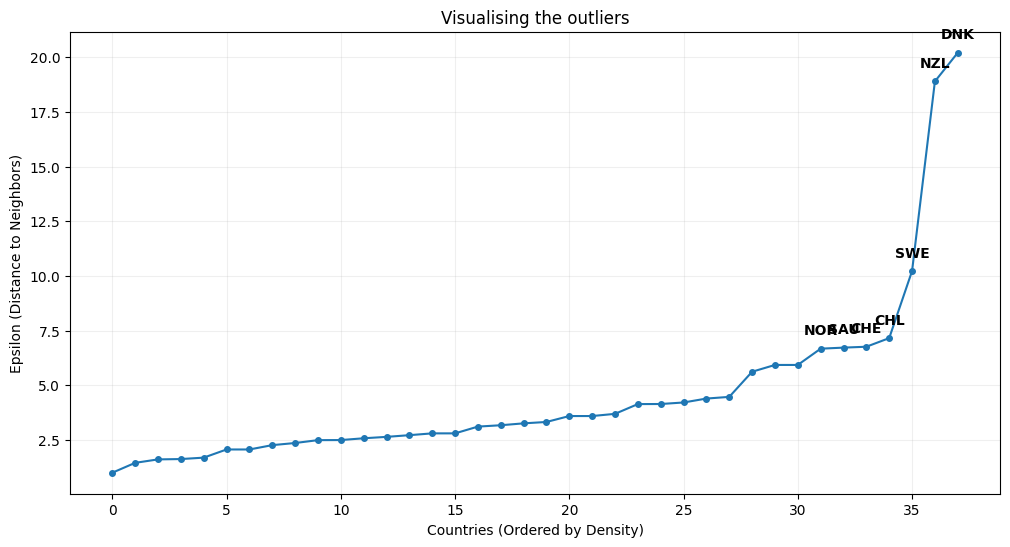

In [113]:
# Distances
neigh = NearestNeighbors(n_neighbors=3)
nbrs = neigh.fit(X_ae_3d)
distances, _ = nbrs.kneighbors(X_ae_3d)

# Get the distance to the 3rd nearest neighbor for each country
dist_to_3rd = distances[:, 2]

# Create a DataFrame 
df_dist = pd.DataFrame({'Country': countries, 'Distance': dist_to_3rd})
df_dist = df_dist.sort_values(by='Distance').reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_dist.index, df_dist['Distance'], marker='o', linestyle='-', markersize=4, color='#1f77b4')

# Label the top outliers
for i in range(len(df_dist)):
    if df_dist.loc[i, 'Distance'] > 6:
        plt.annotate(df_dist.loc[i, 'Country'], (i, df_dist.loc[i, 'Distance']), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title("Visualising the outliers")
plt.xlabel("Countries (Ordered by Density)")
plt.ylabel("Epsilon (Distance to Neighbors)")
plt.grid(True, alpha=0.2)
plt.show()

# Testing how the archetypes changed

In [94]:
import pandas as pd

# Create a summary
summary_df = pd.DataFrame({
    'Country': countries,
    'Cluster_ID': neural_clusters
})

# Sort by Cluster_ID
summary_df = summary_df.sort_values(by='Cluster_ID')

# Print the full list
print("--- Climate Archetype Assignments ---")



for cluster_num in sorted(pd.Series(neural_clusters).unique()):
    
    # Filter the country list to only those in the current cluster
    # Using a list comprehension for a clean, one-line filter
    archetype_countries = [countries[i] for i, c in enumerate(neural_clusters) if c == cluster_num]
    
    # Format the list as a comma-separated string
    countries_str = ", ".join(archetype_countries)
    
    # Print the final formatted block
    print(f"Archetype {cluster_num}:")
    print(f"  Countries: {countries_str}\n")

--- Climate Archetype Assignments ---
Archetype 0:
  Countries: ARG, COL, CZE, IDN, IND, ISR, KOR, MEX, PER, POL, RUS, SAU, ZAF

Archetype 1:
  Countries: AUS, AUT, BEL, CAN, CHE, CHN, DEU, ESP, FRA, GBR, GRC, HUN, IRL, ITA, JPN, NLD, PRT, SVK, TUR

Archetype 2:
  Countries: DNK, NZL

Archetype 3:
  Countries: CHL, FIN, NOR, SWE



# Testing Stability


In [ ]:
import numpy as np

# Creating some noise in the data
noise_factor = 0.05 
X_noisy = X_scaled.values + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_scaled.shape)
X_noisy_tensor = torch.FloatTensor(X_noisy)

# Pass through the  trained model
with torch.no_grad():
    latent_noisy, _ = model(X_noisy_tensor)
    clusters_noisy = kmeans.predict(latent_noisy.numpy())

# See how many shifted with the noise
changes = np.sum(neural_clusters != clusters_noisy)
print(f"Countries that shifted clusters with noise: {changes} out of {len(countries)}")

Countries that shifted clusters with noise: 0 out of 38


# Tweaking values

In [ ]:
import torch
import copy
# changing the data of a country and seeing if it moves to the expected cluster

# Picking Poland (POL) as an example of a coal-reliant country
country_code = 'POL'
idx = np.where(countries == country_code)[0][0]
poland_raw = X_scaled.iloc[idx].copy()

# Tweaking Poland's data to simulate a "Green Poland" scenario
poland_synthetic = poland_raw.copy()

poland_synthetic['coal_electricity_pct'] = -1.5        # Dropping coal significantly
poland_synthetic['renewable_electricity_pct'] = 2.0    # Massive renewable spike
poland_synthetic['total_policy_score'] = 1.8           # Passing aggressive laws
poland_synthetic['log_energy_pc'] = -2.0                # Reducing energy consumption per capita  
poland_synthetic['log_gdp_pc'] = 0.                 # gdp growth          

# Predict where "Green Poland" lands
with torch.no_grad():
    # Pass through original model
    synth_tensor = torch.FloatTensor(poland_synthetic.values).unsqueeze(0)
    latent_synth, _ = model(synth_tensor)
    
    # See which cluster K-Means assigns it to
    new_cluster = kmeans.predict(latent_synth.numpy())[0]

print(f"Original Poland Cluster: {neural_clusters[idx]}")
print(f"Synthetic 'Green' Poland Cluster: {new_cluster}")

with torch.no_grad():
    # Original Poland
    orig_tensor = X_tensor[idx].unsqueeze(0)
    latent_orig, _ = model(orig_tensor)
    
    # Synthetic "Green" Poland 
    latent_synth, _ = model(synth_tensor)

# Calculate the Euclidean distance
distance = torch.norm(latent_orig - latent_synth).item()
print(f"Distance moved in 3D space: {distance:.4f}")


Original Poland Cluster: 1
Synthetic 'Green' Poland Cluster: 1
Distance moved in 3D space: 5.3727


In [ ]:
import torch
import copy
# changing the data of a country and seeing if it moves to the expected cluster

# Picking Poland (POL) as an example of a coal-reliant country
country_code = 'POL'
idx = np.where(countries == country_code)[0][0]
poland_raw = X_scaled.iloc[idx].copy()

# Tweaking Poland's data to simulate a "Green Poland" scenario
poland_synthetic = poland_raw.copy()

poland_synthetic['coal_electricity_pct'] = -1.5        # Dropping coal significantly
poland_synthetic['renewable_electricity_pct'] = 2.0    # Massive renewable spike
poland_synthetic['total_policy_score'] = 1.8           # Passing aggressive laws
poland_synthetic['log_energy_pc'] = -2.0                # Reducing energy consumption per capita  
poland_synthetic['log_gdp_pc'] = 0.8                 # gdp growth          

# Predict where "Green Poland" lands
with torch.no_grad():
    # Pass through original model
    synth_tensor = torch.FloatTensor(poland_synthetic.values).unsqueeze(0)
    latent_synth, _ = model(synth_tensor)
    
    # See which cluster K-Means assigns it to
    new_cluster = kmeans.predict(latent_synth.numpy())[0]

print(f"Original Poland Cluster: {neural_clusters[idx]}")
print(f"Synthetic 'Green' Poland Cluster: {new_cluster}")

with torch.no_grad():
    # Original Poland
    orig_tensor = X_tensor[idx].unsqueeze(0)
    latent_orig, _ = model(orig_tensor)
    
    # Synthetic "Green" Poland 
    latent_synth, _ = model(synth_tensor)

# Calculate the Euclidean distance
distance = torch.norm(latent_orig - latent_synth).item()
print(f"Distance moved in 3D space: {distance:.4f}")


Original Poland Cluster: 1
Synthetic 'Green' Poland Cluster: 1
Distance moved in 3D space: 5.3727


In [21]:
# Get the original cluster for Poland
original_pol_cluster = neural_clusters[idx] 

# Use the EXISTING kmeans object 
synthetic_pol_cluster = kmeans.predict(latent_synth.numpy())[0]

if original_pol_cluster == synthetic_pol_cluster:
    print(f"Result: Poland movedbut is STILL in Archetype {original_pol_cluster}.")
    print("This means the cluster is huge, or other features (GDP/Risk) are holding it back.")
else:
    print(f"Result: SUCCESS! Poland switched from Archetype {original_pol_cluster} to {synthetic_pol_cluster}.")

Result: Poland movedbut is STILL in Archetype 1.
This means the cluster is huge, or other features (GDP/Risk) are holding it back.


In [ ]:
# Check distances to every cluster center
distances_to_centers = []
for i, center in enumerate(kmeans.cluster_centers_):
    dist = np.linalg.norm(latent_synth.numpy() - center)
    distances_to_centers.append(dist)
    print(f"Distance to Archetype {i} Center: {dist:.4f}")

# Who was the winner
best_cluster = np.argmin(distances_to_centers)
print(f"\nMathematically closest: Archetype {best_cluster}")

Distance to Archetype 0 Center: 9.2629
Distance to Archetype 1 Center: 1.3475
Distance to Archetype 2 Center: 11.8185
Distance to Archetype 3 Center: 8.9153

Mathematically closest: Archetype 1


# Testing australia shift

In [24]:
# Testing with Australia (AUS) because it is more likely on the edge
country_code = 'AUS'
idx = np.where(countries == country_code)[0][0]
aus_raw = X_scaled.iloc[idx].copy()

# Transform
aus_synthetic = aus_raw.copy()

aus_synthetic['coal_electricity_pct'] = -2.5       # Near zero coal
aus_synthetic['renewable_electricity_pct'] = 3.5   # Massive solar/wind adoption
aus_synthetic['total_policy_score'] = 2.5          # Top-tier global policy
aus_synthetic['log_energy_pc'] = -1.5             # High efficiency


# Predict shift
with torch.no_grad():
    synth_tensor = torch.FloatTensor(aus_synthetic.values).unsqueeze(0)
    latent_synth, _ = model(synth_tensor)
    new_cluster = kmeans.predict(latent_synth.numpy())[0]

# Check the distance and cluster
orig_cluster = neural_clusters[idx]
print(f"Original Australia Cluster: {orig_cluster}")
print(f"Synthetic 'Green' Australia Cluster: {new_cluster}")

with torch.no_grad():
    latent_orig, _ = model(X_tensor[idx].unsqueeze(0))
    distance = torch.norm(latent_orig - latent_synth).item()

print(f"Distance moved in Latent Space: {distance:.4f}")

Original Australia Cluster: 3
Synthetic 'Green' Australia Cluster: 1
Distance moved in Latent Space: 3.4759
